# Wildfire Susceptibility: a Random Forest Baseline

This notebook builds an end-to-end machine-learning pipeline that ranks
wildfire susceptibility from static landscape predictors and yearly
burned-area rasters.

**Scientific context.** Wildfire susceptibility mapping asks: given only
terrain, vegetation, and accessibility, which parts of the landscape are most
similar to places that have historically burned? The output is a *relative
ranking*, not a calibrated annual ignition probability — weather, fuel
moisture, and human ignition patterns are not modelled here.

**Pipeline overview:**

| # | Section | Purpose |
|---|---------|---------|
| 1 | Setup | Environment, constants, paths |
| 2 | Data loading | Raster ingestion and analysis mask |
| 3 | Burned-area target | Fire rasters and temporal split |
| 4 | Feature engineering | Aspect encoding, vegetation one-hot |
| 5 | Training set construction | Pseudo-absences and train/val split |
| 6 | Exploratory class comparison | Burned vs unburned contrasts |
| 7 | Model tuning | Hyperparameter grid search |
| 8 | Model fitting | Final pre-2016 model |
| 9 | Hold-out evaluation | ROC-AUC, recall@top%, score distributions |
| 10 | Threshold decisions | Percentile-based operational thresholds |
| 11 | Model explanation | Permutation importance (MDA) |
| 12 | Susceptibility map | Spatial prediction and overlay |

**Key design choices:**

- The row unit is one valid 100 m pixel.
- Positive label: pixel burned at least once in the period.
- Training uses balanced pseudo-absences; hold-out keeps real imbalance.
- The model output is a relative susceptibility score.
- Main caveats: nearby pixels are spatially autocorrelated, predictors are
  assumed time-invariant.

## 1. Setup

This cell loads the lesson setup script. In Colab it downloads the script
from GitHub; the script then installs dependencies and clones the data.
# Features as they appear in the raw rasters.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

setup_path = Path("lesson_setup.py")
if not setup_path.exists():
    urlretrieve(
        "https://raw.githubusercontent.com/mirkodandrea/wildfire-susceptibility-ml-lesson/main/lesson_setup.py",
        setup_path,
    )

from lesson_setup import *  # noqa: F403
import rasterio

RANDOM_STATE = 42
HOLDOUT_START_YEAR = 2016

DATA_DIR = Path("data")
FIRE_RASTER_DIR = DATA_DIR / "fires"

RASTER_PATHS = {
    "elevation": DATA_DIR / "elevation.tif",
    "slope": DATA_DIR / "slope.tif",
    "aspect": DATA_DIR / "aspect.tif",
    "vegetation": DATA_DIR / "vegetation.tif",
    "urban_distance": DATA_DIR / "urban_distance.tif",
    "roads_distance": DATA_DIR / "roads_distance.tif",
}

# Features as they appear in the raw rasters.
RASTER_FEATURES = [
    "elevation",
    "slope",
    "aspect",
    "urban_distance",
    "roads_distance",
    "vegetation",
]

# Features as they enter the model (after engineering).
FEATURES = [
    "elevation",
    "slope",
    "aspect_eastness",
    "aspect_northness",
    "urban_distance",
    "roads_distance",
    "vegetation",
]


def continuous_features(feature_list):
    """Return only the continuous (non-categorical) features.

    Vegetation is categorical and handled separately via one-hot encoding.
    """
    return [f for f in feature_list if f != "vegetation"]


VEGETATION_NAMES = {
    # Mixed broadleaf forests
    3112: "Warm-climate mixed forest",
    3113: "Moist-climate mixed forest",
    313: "Mixed forest",
    # Dominant tree-species forests
    3114: "Beech forest",
    3115: "Chestnut forest",
    3116: "Chestnut orchard",
    # Evergreen and conifer forests
    3111: "Evergreen dry forest",
    312: "Coniferous forest",
    # Water-associated vegetation
    3117: "Riparian vegetation",
    # Shrub and transitional vegetation
    322: "Shrubland and scrub",
    323: "Mediterranean evergreen scrub",
    324: "Woodland-shrub transition",
}

VEGETATION_CODES = list(VEGETATION_NAMES)
VEGETATION_FEATURE_COLUMNS = [f"vegetation_{code}" for code in VEGETATION_CODES]

# Colors for vegetation classes, chosen to be visually distinct
VEGETATION_COLORS = {
    3112: "#5aae61",
    3113: "#1b7837",
    313: "#00441b",
    3114: "#74c476",
    3115: "#238b45",
    3116: "#8c6d31",
    3111: "#2b8c4b",
    312: "#006d2c",
    3117: "#2b8cbe",
    322: "#d8b365",
    323: "#b35806",
    324: "#a6d96a",
}
VEGETATION_CMAP = ListedColormap([VEGETATION_COLORS[code] for code in VEGETATION_CODES])
VEGETATION_NORM = BoundaryNorm(
    np.arange(-0.5, len(VEGETATION_CODES) + 0.5),
    VEGETATION_CMAP.N,
)


def clean_axes(ax):
    """Remove top and right spines for a cleaner plot."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## 2. Data loading and analysis mask

*Learning objective:* understand how raster grids become arrays, and why a
consistent validity mask is essential.

All rasters share the same 100 m grid. The `vegetation` raster defines the
reference grid shape and coordinate transform. Each raster is read as a 2-D
NumPy array.

The **analysis mask** restricts all subsequent operations to pixels where
every predictor is available and meaningful. Pixels with missing vegetation
(or code 0, which indicates non-vegetated/urban areas) are excluded first;
then any pixel where a continuous predictor is missing is also excluded.
This ensures a consistent footprint for sampling, evaluation, and mapping.

In [2]:
with rasterio.open(RASTER_PATHS["vegetation"]) as src:
    TEMPLATE_TRANSFORM = src.transform
    TEMPLATE_SHAPE = (src.height, src.width)

extent = (
    TEMPLATE_TRANSFORM.c,
    TEMPLATE_TRANSFORM.c + TEMPLATE_TRANSFORM.a * TEMPLATE_SHAPE[1],
    TEMPLATE_TRANSFORM.f + TEMPLATE_TRANSFORM.e * TEMPLATE_SHAPE[0],
    TEMPLATE_TRANSFORM.f,
)

raster_arrays = {}
for name, path in RASTER_PATHS.items():
    with rasterio.open(path) as src:
        raster_arrays[name] = src.read(1, masked=True).astype("float32").filled(np.nan)

In [3]:
vegetation = raster_arrays["vegetation"]
analysis_mask = np.isfinite(vegetation) & (vegetation != 0)

valid_mask = analysis_mask.copy()
for feature in continuous_features(RASTER_FEATURES):
    raster_arrays[feature] = np.where(analysis_mask, raster_arrays[feature], np.nan)
    valid_mask &= np.isfinite(raster_arrays[feature])

valid_pixel_count = int(valid_mask.sum())
display(Markdown("### Valid analysis pixels"))
display(valid_pixel_count)

### Valid analysis pixels

398697

### Predictor maps

Mapping each predictor is a quick sanity check: look for spatial structure,
missing-data holes, etc.

Text(0.01, 0.98, 'Continuous predictor rasters')

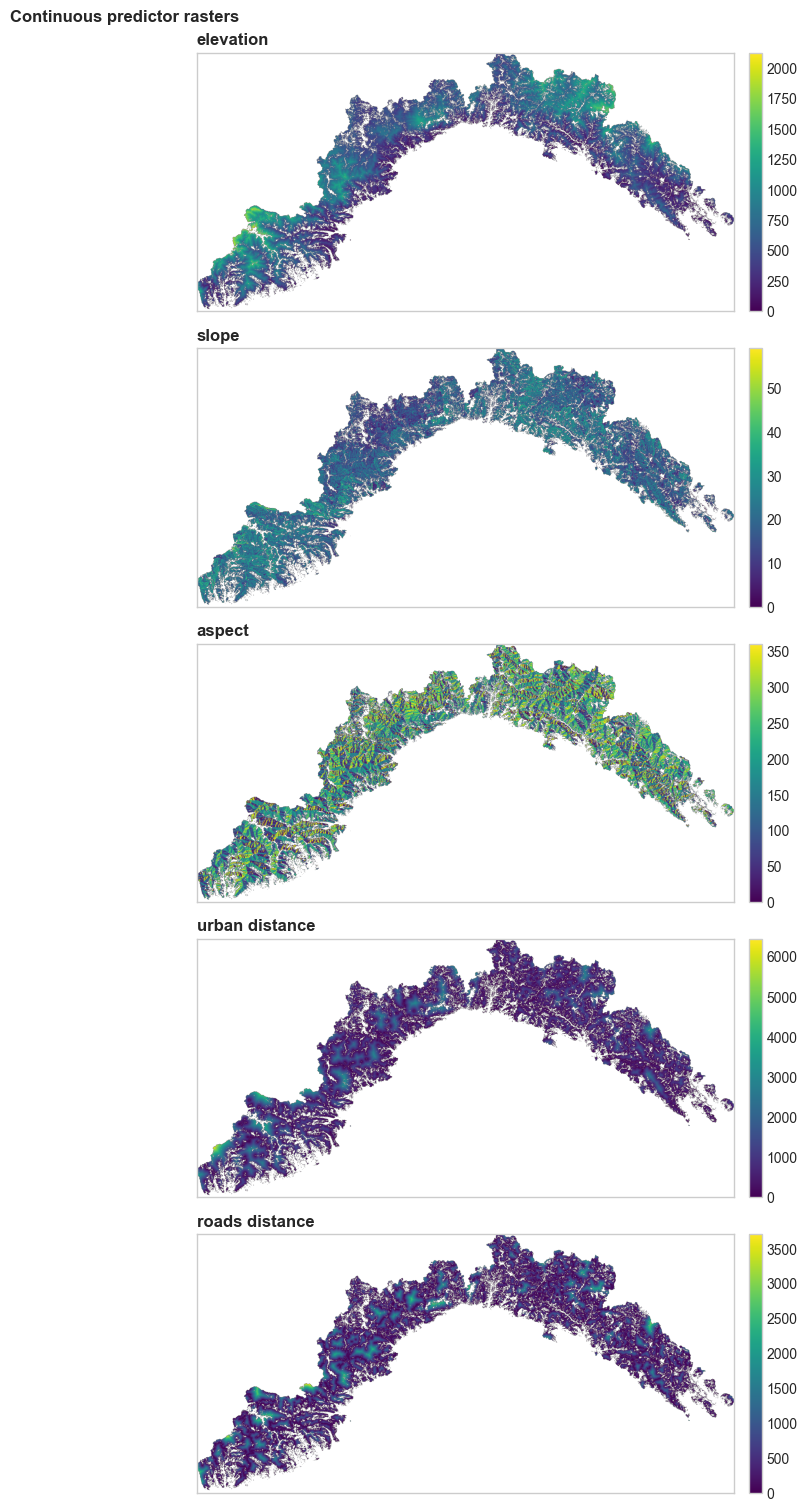

In [4]:
fig, axes = plt.subplots(
    len(continuous_features(RASTER_FEATURES)),
    1,
    figsize=(8, 3 * len(continuous_features(RASTER_FEATURES))),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, feature in zip(axes, continuous_features(RASTER_FEATURES)):
    feature_map = np.where(analysis_mask, raster_arrays[feature], np.nan)
    image = ax.imshow(feature_map, extent=extent, origin="upper", cmap="viridis")
    fig.colorbar(image, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title(feature.replace("_", " "), loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Continuous predictor rasters", x=0.01, ha="left", fontweight="bold")

[]

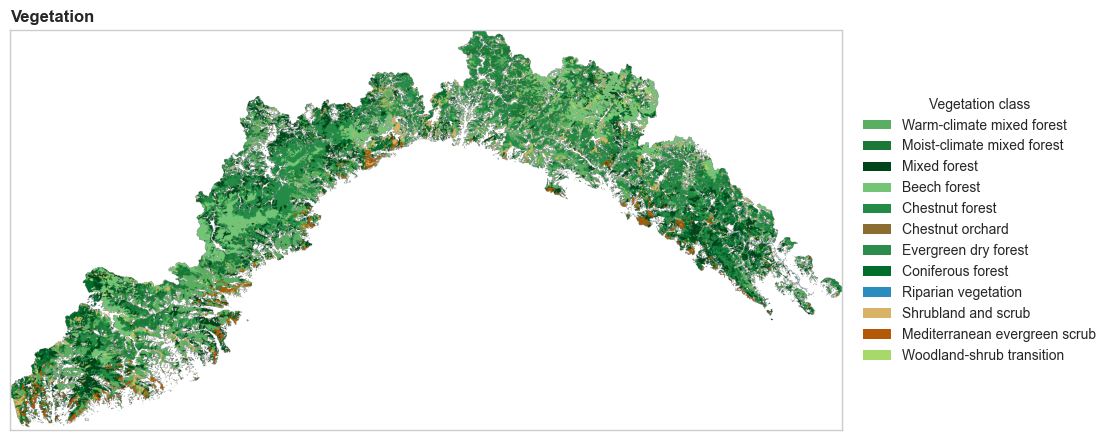

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
feature_map = np.where(analysis_mask, raster_arrays["vegetation"], np.nan)
code_to_index = {code: index for index, code in enumerate(VEGETATION_CODES)}
vegetation_map = np.full(feature_map.shape, np.nan, dtype=float)
for code, index in code_to_index.items():
    vegetation_map[feature_map == code] = index

ax.imshow(
    vegetation_map,
    extent=extent,
    origin="upper",
    cmap=VEGETATION_CMAP,
    norm=VEGETATION_NORM,
)
legend_handles = [
    Patch(facecolor=VEGETATION_COLORS[code], edgecolor="none", label=VEGETATION_NAMES[code])
    for code in VEGETATION_CODES
    if np.any(feature_map == code)
]
ax.legend(
    handles=legend_handles,
    title="Vegetation class",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
)
ax.set_title("Vegetation", loc="left", fontweight="bold")
ax.set_xticks([])
ax.set_yticks([])

## 3. Burned-area target and temporal split

*Learning objective:* understand how yearly fire rasters become supervised
labels, and why the temporal split matters for honest evaluation.

Each yearly fire raster is a binary grid: `1` = pixel burned that year,
`0` = not burned. We combine years with a logical OR to get period masks.

The **temporal split** separates training data (fires before 2016) from
hold-out evaluation (fires 2016–2022). This simulates an operational
scenario: can a model trained on past fire patterns rank future fire
locations?

> ⚠️ **Assumption:** predictor rasters (elevation, slope, vegetation,
> distances) are treated as time-invariant. In reality, vegetation and
> urban extent change over 25 years. This approximation is acceptable for
> a baseline but should be noted when interpreting results.

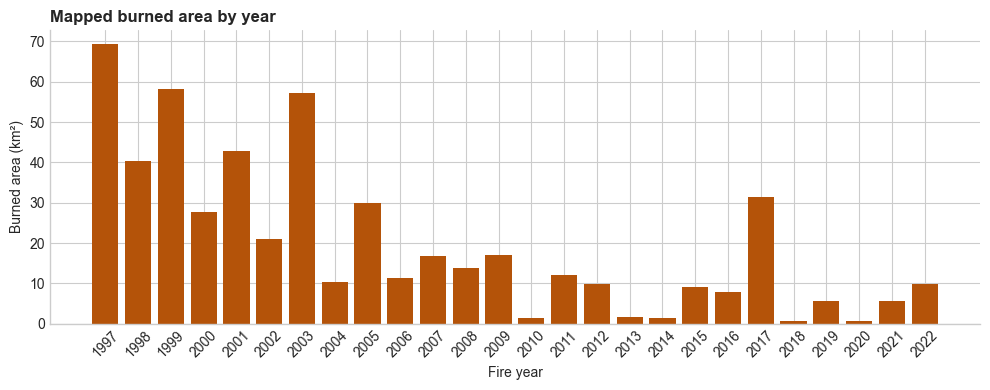

In [6]:
fire_years = list(range(1997, 2023))

fire_masks = {}
for year in fire_years:
    path = FIRE_RASTER_DIR / f"fire_{year}.tiff"
    with rasterio.open(path) as src:
        fire_mask = src.read(1).astype(bool)
        fire_masks[year] = fire_mask & valid_mask

pixel_area_km2 = abs(TEMPLATE_TRANSFORM.a * TEMPLATE_TRANSFORM.e) / 1_000_000
fire_summary_df = pd.DataFrame(
    [
        {
            "fire_year": year,
            "burned_pixels": int(mask.sum()),
            "burned_area_km2": round(int(mask.sum()) * pixel_area_km2, 2),
        }
        for year, mask in fire_masks.items()
    ]
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    fire_summary_df["fire_year"].astype(str),
    fire_summary_df["burned_area_km2"],
    color="#b45309",
)
ax.set_title("Mapped burned area by year", loc="left", fontweight="bold")
ax.set_xlabel("Fire year")
ax.set_ylabel("Burned area (km²)")
ax.tick_params(axis="x", rotation=45)
clean_axes(ax)
fig.tight_layout()

### Define the temporal split

In [7]:
train_years = [year for year in fire_years if year < HOLDOUT_START_YEAR]
test_years = [year for year in fire_years if year >= HOLDOUT_START_YEAR]

train_burned_mask = combined_fire_mask(fire_masks, train_years)
test_burned_mask = combined_fire_mask(fire_masks, test_years)

temporal_split_df = pd.DataFrame(
    [
        {
            "role": "training pool",
            "years": f"{min(train_years)}–{max(train_years)}",
            "n_years": len(train_years),
            "burned_pixels": int(train_burned_mask.sum()),
            "burned_share_%": round(float(train_burned_mask.sum() / valid_pixel_count) * 100, 2),
        },
        {
            "role": "hold-out test",
            "years": f"{min(test_years)}–{max(test_years)}",
            "n_years": len(test_years),
            "burned_pixels": int(test_burned_mask.sum()),
            "burned_share_%": round(float(test_burned_mask.sum() / valid_pixel_count) * 100, 2),
        },
    ]
)
display(Markdown("### Temporal split"))
display(temporal_split_df)

### Temporal split

,role,years,n_years,burned_pixels,burned_share_%
0,training pool,1997–2015,19,35912,9.01
1,hold-out test,2016–2022,7,5806,1.46


Text(0.01, 0.98, 'Burned labels by period')

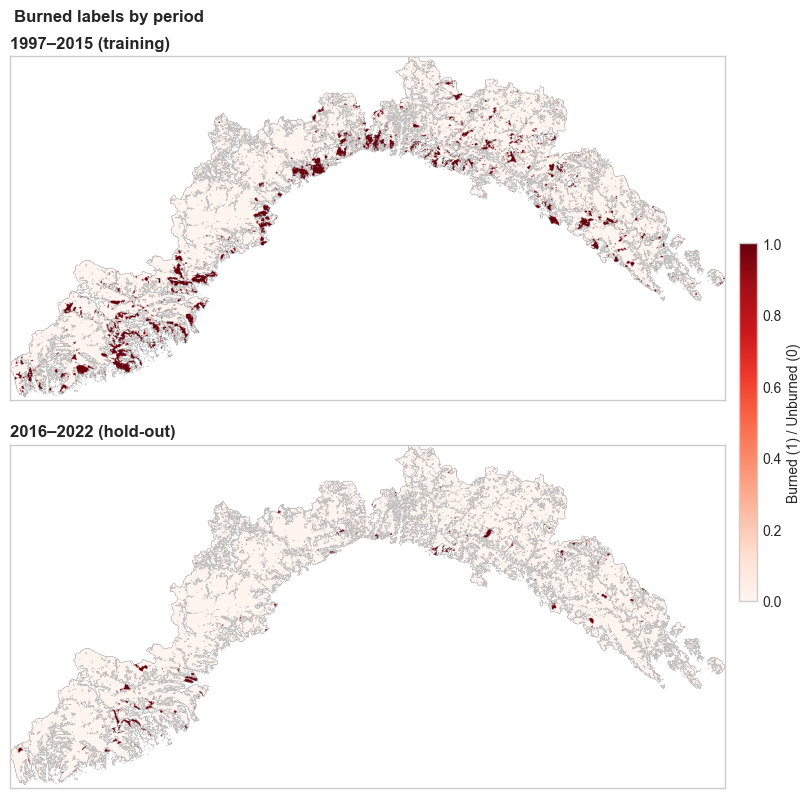

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), constrained_layout=True)

for ax, period_name, label_mask in [
    (axes[0], f"{min(train_years)}–{max(train_years)} (training)", train_burned_mask),
    (axes[1], f"{min(test_years)}–{max(test_years)} (hold-out)", test_burned_mask),
]:
    label_map = np.where(valid_mask, label_mask.astype(float), np.nan)
    image = ax.imshow(label_map, extent=extent, origin="upper", cmap="Reds", vmin=0, vmax=1)
    ax.set_title(period_name, loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02, label="Burned (1) / Unburned (0)")
fig.suptitle("Burned labels by period", x=0.01, ha="left", fontweight="bold")

## 4. Feature engineering

*Learning objective:* understand why raw raster values cannot always be used
directly, and how to transform circular and categorical predictors.

Two predictors need transformation before modelling:

### Aspect (circular variable)

Aspect is measured in degrees (0–360). The problem: 1° and 359° are nearly
the same direction (north), yet a model would see them as 358 units apart.
The standard fix decomposes the angle into two orthogonal components:

- `aspect_eastness = sin(aspect°)` → ranges from −1 (west) to +1 (east)
- `aspect_northness = cos(aspect°)` → ranges from −1 (south) to +1 (north)

These two features together preserve direction information without any
artificial discontinuity.

### Vegetation (unordered categorical)

Vegetation codes (e.g., 3111, 322) have no meaningful numeric ordering.
Treating them as a continuous variable would imply that code 3111 is "between"
codes 312 and 3112, which is ecologically meaningless.

**One-hot encoding** creates one binary column per vegetation class. Each
pixel gets a `1` in the column matching its class and `0` elsewhere. This
lets the model learn class-specific effects without assuming any ordering.

> For tree-based models, one-hot encoding is not strictly required (ordinal
> encoding also works), but it makes feature importance directly interpretable
> per vegetation class, and it is the standard approach in scikit-learn.

In [9]:
def add_aspect_features(frame):
    """Replace raw aspect degrees with eastness and northness components."""
    engineered = frame.copy()
    aspect_radians = np.deg2rad(engineered["aspect"])
    engineered["aspect_eastness"] = np.sin(aspect_radians)
    engineered["aspect_northness"] = np.cos(aspect_radians)
    return engineered


def one_hot_encode_vegetation(frame):
    """Return one binary column per vegetation class from the fixed class list."""
    vegetation_codes = frame["vegetation"].astype(int)
    vegetation_dummies = pd.get_dummies(
        vegetation_codes,
        prefix="vegetation",
        dtype=int,
    )
    return vegetation_dummies.reindex(
        columns=VEGETATION_FEATURE_COLUMNS,
        fill_value=0,
    ).reset_index(drop=True)


def make_features(frame, feature_columns=None):
    """Build the numeric model matrix used by the Random Forest.

    Steps:
    1. Compute aspect_eastness and aspect_northness (if not already present).
    2. Select the continuous engineered features.
    3. One-hot encode vegetation.
    4. If feature_columns is provided, reindex to match training columns exactly.
    """
    has_aspect_components = {"aspect_eastness", "aspect_northness"}.issubset(frame.columns)
    needs_aspect_engineering = "aspect" in frame.columns and not has_aspect_components
    engineered_frame = add_aspect_features(frame) if needs_aspect_engineering else frame

    numeric_features = engineered_frame[continuous_features(FEATURES)].reset_index(drop=True)
    vegetation_features = one_hot_encode_vegetation(engineered_frame)

    model_features = pd.concat([numeric_features, vegetation_features], axis=1)

    if feature_columns is not None:
        model_features = model_features.reindex(columns=feature_columns, fill_value=0)

    return model_features

### Build the shared feature table

One row per valid pixel, with coordinates and all engineered predictors.
This table is built once and then joined with period-specific labels.

In [10]:
rows, cols = np.where(valid_mask)
feature_table = pixel_frame(
    rows,
    cols,
    target=0,
    sample_type="valid_pixel",
    template_transform=TEMPLATE_TRANSFORM,
    raster_arrays=raster_arrays,
    features=RASTER_FEATURES,
)
feature_table = add_aspect_features(feature_table)
feature_table = feature_table.drop(columns=["target", "sample_type"])

display(Markdown("### Feature table (first rows)"))
display(feature_table.head())

### Feature table (first rows)

,row,col,x,y,elevation,slope,aspect,urban_distance,roads_distance,vegetation,aspect_eastness,aspect_northness
0,1,1158,1.494904e+06,4.946934e+06,563.0,20.843185,174.158386,900.000000,905.538574,3115,0.101779,-0.994807
1,2,1156,1.494704e+06,4.946834e+06,527.0,23.599121,168.111343,824.621094,854.400330,3115,0.206011,-0.978550
2,2,1157,1.494804e+06,4.946834e+06,525.0,26.699856,175.295486,806.225769,824.621094,3115,0.082017,-0.996631
3,2,1158,1.494904e+06,4.946834e+06,519.0,24.512413,183.772278,800.000000,806.225769,3115,-0.065791,-0.997833
4,2,1159,1.495004e+06,4.946834e+06,532.0,20.421495,194.782715,800.000000,800.000000,3115,-0.255154,-0.966900


## 5. Training set construction

*Learning objective:* understand pseudo-absence sampling and why class
balance matters for training.

### Why pseudo-absences?

Fire is rare: typically only 1–5% of the landscape burns in any period.
If we trained on all pixels, the model could achieve 95%+ accuracy by
predicting "unburned" everywhere — useless for susceptibility ranking.

**Pseudo-absence sampling** selects a subset of unburned pixels as the
negative class. We use a 1:1 ratio (equal burned and unburned samples)
because:

1. It gives both classes equal weight during fitting, forcing the model to
   learn discriminative features rather than base-rate shortcuts.
2. It is the simplest balanced design and a standard baseline in species
   distribution modelling (which shares this structure).
3. The model's predicted scores no longer reflect landscape prevalence —
   but we explicitly want a *ranking*, not a probability estimate.

Alternative ratios (1:2, 1:5, 1:10) shift the model toward higher
specificity at the cost of sensitivity. For a first baseline, 1:1 is the
most transparent choice.

In [11]:
def add_period_labels(features, burned_mask, period_name):
    """Join the feature table with a period-specific burned mask."""
    period_df = features.copy()
    period_df["target"] = burned_mask[period_df["row"], period_df["col"]].astype(int)
    period_df["sample_type"] = np.where(period_df["target"] == 1, "burned", "unburned")
    period_df["period"] = period_name
    period_df["target_name"] = period_df["target"].map({0: "unburned", 1: "burned"})
    return period_df


# Label all valid pixels for training period (needed to sample from).
train_period_df = add_period_labels(
    feature_table,
    train_burned_mask,
    f"{min(train_years)}–{max(train_years)}",
)

# Balanced training pool: all burned + equal random sample of unburned.
burned_train_df = train_period_df.loc[train_period_df["target"] == 1]
unburned_train_df = train_period_df.loc[train_period_df["target"] == 0].sample(
    n=len(burned_train_df),
    random_state=RANDOM_STATE,
)
# Shuffle the combined training pool to mix burned and unburned samples.
train_pool_df = pd.concat([burned_train_df, unburned_train_df], ignore_index=True)\
    .sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

display(Markdown("### Training pool sample (balanced 1:1)"))
display(train_pool_df.head())

### Training pool sample (balanced 1:1)

,row,col,x,y,elevation,slope,aspect,urban_distance,roads_distance,vegetation,aspect_eastness,aspect_northness,target,sample_type,period,target_name
0,317,768,1.455904e+06,4.915334e+06,581.0,19.239143,82.798622,1341.640747,1170.469971,3115,0.992112,0.125357,0,unburned,1997–2015,unburned
1,206,1323,1.511404e+06,4.926434e+06,733.0,18.362600,273.670532,0.000000,0.000000,3113,-0.997949,0.064019,0,unburned,1997–2015,unburned
2,649,541,1.433204e+06,4.882134e+06,184.0,19.080738,184.144623,806.225769,316.227783,323,-0.072274,-0.997385,1,burned,1997–2015,burned
3,926,99,1.389004e+06,4.854434e+06,221.0,19.826370,162.444519,565.685425,223.606796,312,0.301629,-0.953425,0,unburned,1997–2015,unburned
4,251,1085,1.487604e+06,4.921934e+06,267.0,33.381763,50.542347,360.555115,509.901947,3112,0.772095,0.635508,0,unburned,1997–2015,unburned


## 6. Exploratory class comparison

*Learning objective:* check whether burned and unburned pixels have
distinguishable predictor distributions *before* fitting a model.

These summaries use the balanced pre-2016 training pool. They describe
the modelling contrast (burned vs sampled pseudo-absence), not the true
landscape prevalence of each predictor value.

In [12]:
class_summary_df = (
    train_pool_df.groupby("target_name", observed=True)[continuous_features(FEATURES)]
    .median()
    .T.rename_axis("feature")
    .reset_index()
)
display(Markdown("### Class-wise median (continuous predictors)"))
display(class_summary_df.style.format(precision=2))

### Class-wise median (continuous predictors)

target_name,feature,burned,unburned
0,elevation,467.00,565.00
1,slope,21.34,18.80
2,aspect_eastness,0.16,0.00
3,aspect_northness,-0.56,0.00
4,urban_distance,583.10,583.10
5,roads_distance,316.23,300.00


In [13]:
vegetation_summary_df = (
    pd.crosstab(
        train_pool_df["vegetation"].map(VEGETATION_NAMES).fillna(
            train_pool_df["vegetation"].astype(str)
        ),
        train_pool_df["target_name"],
        normalize="columns",
    )
    .mul(100)
    .round(1)
    .sort_values("burned", ascending=False)
    .head(8)
)
display(Markdown("### Top vegetation classes (% within each label)"))
display(vegetation_summary_df)




### Top vegetation classes (% within each label)

target_name,burned,unburned
vegetation,,
Warm-climate mixed forest,21.0,15.9
Mediterranean evergreen scrub,18.7,1.7
Shrubland and scrub,13.3,2.8
Mixed forest,11.3,13.7
Chestnut forest,10.7,26.7
Coniferous forest,10.1,8.4
Woodland-shrub transition,6.3,5.6
Moist-climate mixed forest,4.5,12.4


### Distribution plots

Blue = sampled unburned (pseudo-absence). Red = burned.

Strong separation suggests a useful predictor; heavy overlap means the
model needs feature combinations rather than single thresholds.

Text(0.01, 0.98, 'Continuous predictor distributions by class')

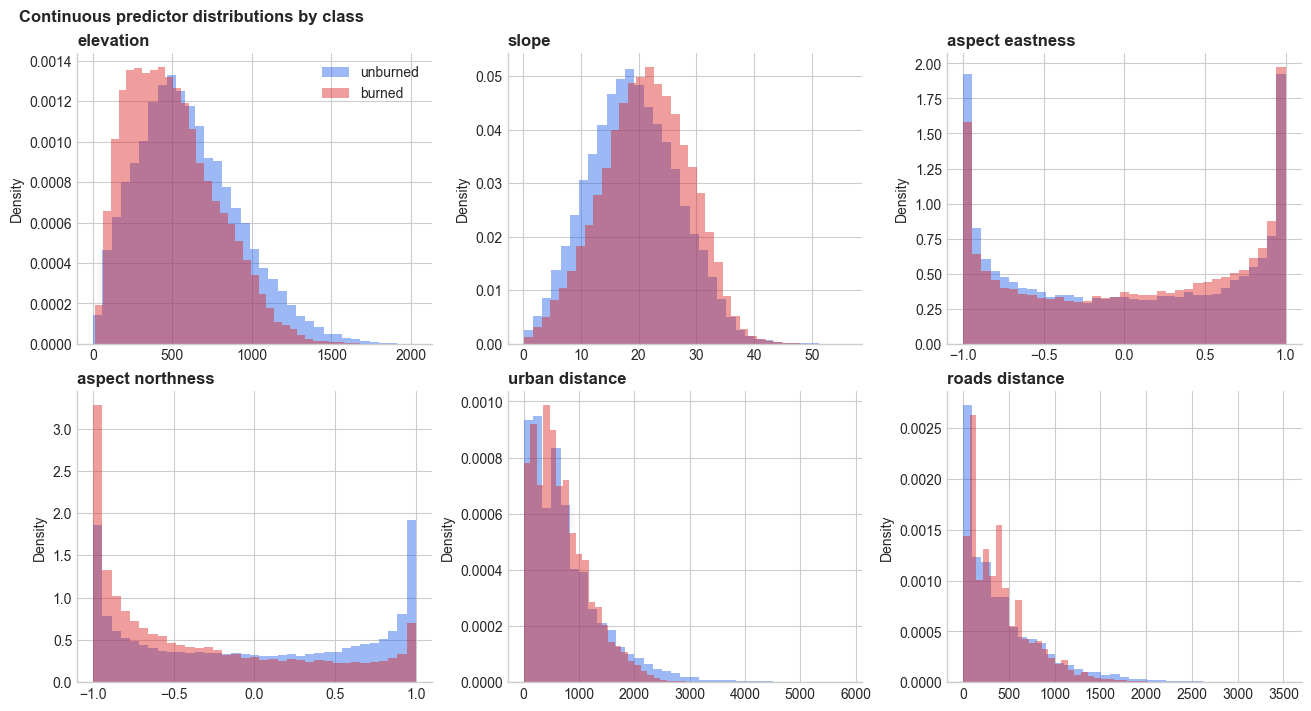

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
axes = axes.ravel()

for ax, feature in zip(axes, continuous_features(FEATURES)):
    for target, label, color in [(0, "unburned", "#2563eb"), (1, "burned", "#dc2626")]:
        ax.hist(
            train_pool_df.loc[train_pool_df["target"] == target, feature],
            bins=35,
            density=True,
            alpha=0.45,
            color=color,
            label=label,
        )
    ax.set_title(feature.replace("_", " "), loc="left", fontweight="bold")
    ax.set_ylabel("Density")
    clean_axes(ax)

axes[0].legend(frameon=False)
fig.suptitle("Continuous predictor distributions by class", x=0.01, ha="left", fontweight="bold")

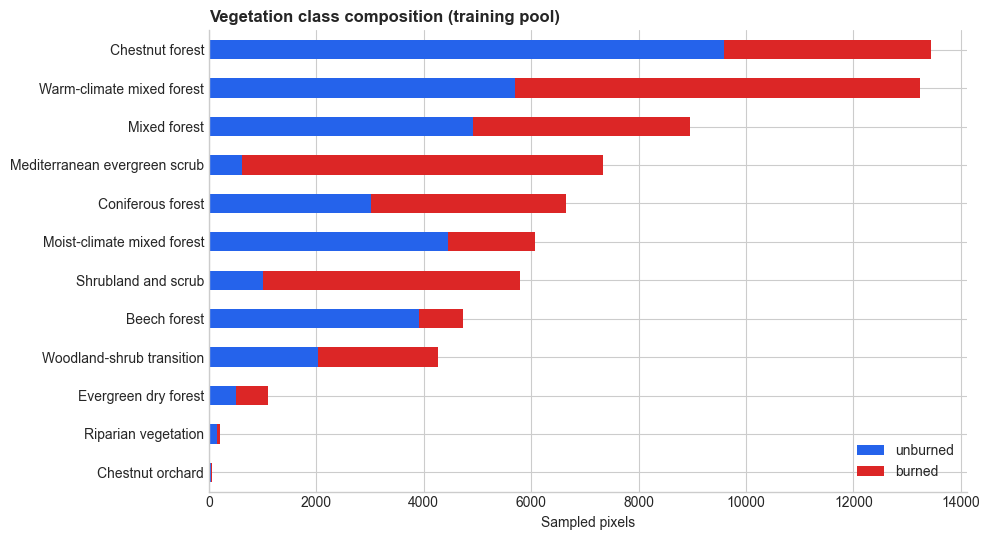

In [15]:
vegetation_plot_df = (
    pd.crosstab(
        train_pool_df["vegetation"].map(VEGETATION_NAMES).fillna(
            train_pool_df["vegetation"].astype(str)
        ),
        train_pool_df["target_name"],
    )
    .reindex(columns=["unburned", "burned"], fill_value=0)
    .assign(total=lambda frame: frame.sum(axis=1))
    .sort_values("total", ascending=True)
)
vegetation_count_plot_df = vegetation_plot_df[["unburned", "burned"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
vegetation_count_plot_df.plot.barh(stacked=True, ax=ax, color=["#2563eb", "#dc2626"])
ax.set_title("Vegetation class composition (training pool)", loc="left", fontweight="bold")
ax.set_xlabel("Sampled pixels")
ax.set_ylabel("")
clean_axes(ax)
ax.legend(title="", frameon=False)
fig.tight_layout()

Pre-2016 burned pixels tend to be
lower in elevation (467 m vs 565 m), steeper (21.3° vs 18.8°), and more
south-facing (aspect_northness −0.56 vs 0.00) than the sampled unburned
pixels. Mediterranean evergreen scrub (18.7% vs 1.7%) and shrubland (13.3%
vs 2.8%) are strongly over-represented among burned samples, while chestnut
forests (10.7% vs 26.7%) and moist-climate forests (4.5% vs 12.4%) are
under-represented. Warm-climate mixed forests show moderate enrichment in
burned pixels (21.0% vs 15.9%), suggesting vegetation type is a key
discriminator for susceptibility ranking.

### Hold-out set: no balancing

With the training pool explored above, we can now finalise the dataset
structure. The 2016–2022 hold-out set keeps *every* valid pixel. This
preserves the real rare-event imbalance so that evaluation metrics reflect
operational performance, not artificial balance.

In [16]:
test_df = add_period_labels(
    feature_table,
    test_burned_mask,
    f"{min(test_years)}–{max(test_years)}",
)

### Train / validation split

The validation split is internal to the balanced pre-2016 training pool.
Stratification preserves the 50/50 ratio in both splits. This validation
set is used only for hyperparameter tuning; the 2016–2022 hold-out remains
untouched until final evaluation.

> ⚠️ **Spatial autocorrelation caveat:** this random split does not
> respect spatial proximity. Nearby pixels share terrain, vegetation, and
> fire history, so validation AUC from this split is likely *optimistic*
> compared to truly independent spatial evaluation. The temporal hold-out
> (2016–2022) provides a harder test.
> This is acceptable as a first baseline for a lesson, a better approach would be to use
> spatial blocks or a spatial cross-validation strategy.

In [17]:
train_model_df, validation_df = train_test_split(
    train_pool_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_pool_df["target"],
)

In [18]:
dataset_summary_df = pd.DataFrame(
    [
        {
            "dataset": "balanced training pool",
            "period": train_pool_df["period"].iloc[0],
            "rows": len(train_pool_df),
            "burned": int(train_pool_df["target"].sum()),
            "unburned": int((train_pool_df["target"] == 0).sum()),
            "burned_share": f"{train_pool_df['target'].mean():.1%}",
        },
        {
            "dataset": "  ↳ model training split",
            "period": train_model_df["period"].iloc[0],
            "rows": len(train_model_df),
            "burned": int(train_model_df["target"].sum()),
            "unburned": int((train_model_df["target"] == 0).sum()),
            "burned_share": f"{train_model_df['target'].mean():.1%}",
        },
        {
            "dataset": "  ↳ validation split",
            "period": validation_df["period"].iloc[0],
            "rows": len(validation_df),
            "burned": int(validation_df["target"].sum()),
            "unburned": int((validation_df["target"] == 0).sum()),
            "burned_share": f"{validation_df['target'].mean():.1%}",
        },
        {
            "dataset": "hold-out test (full landscape)",
            "period": test_df["period"].iloc[0],
            "rows": len(test_df),
            "burned": int(test_df["target"].sum()),
            "unburned": int((test_df["target"] == 0).sum()),
            "burned_share": f"{test_df['target'].mean():.1%}",
        },
    ]
)
display(Markdown("### Dataset summary"))
display(dataset_summary_df)

### Dataset summary

,dataset,period,rows,burned,unburned,burned_share
0,balanced training pool,1997–2015,71824,35912,35912,50.0%
1,↳ model training split,1997–2015,57459,28730,28729,50.0%
2,↳ validation split,1997–2015,14365,7182,7183,50.0%
3,hold-out test (full landscape),2016–2022,398697,5806,392891,1.5%


### Encode features for modelling

Apply one-hot encoding to vegetation and select the final model columns.
The encoding vocabulary is defined on the training split and reused
everywhere to guarantee consistent column alignment.

In [19]:
X_train = make_features(train_model_df)
FEATURE_COLUMNS = X_train.columns

X_valid = make_features(validation_df, FEATURE_COLUMNS)
X_test = make_features(test_df, FEATURE_COLUMNS)

y_train = train_model_df["target"]
y_valid = validation_df["target"]
y_test = test_df["target"]

display(Markdown(f"### Encoded feature matrix: {len(FEATURE_COLUMNS)} columns"))
display(list(FEATURE_COLUMNS))

### Encoded feature matrix: 18 columns

['elevation',
 'slope',
 'aspect_eastness',
 'aspect_northness',
 'urban_distance',
 'roads_distance',
 'vegetation_3112',
 'vegetation_3113',
 'vegetation_313',
 'vegetation_3114',
 'vegetation_3115',
 'vegetation_3116',
 'vegetation_3111',
 'vegetation_312',
 'vegetation_3117',
 'vegetation_322',
 'vegetation_323',
 'vegetation_324']

## 7. Model tuning

*Learning objective:* understand how grid search explores hyperparameter
combinations and why we use a predefined validation fold.

### What are hyperparameters?

A Random Forest has settings that *you* choose before training — these are
called **hyperparameters**. They control how the forest is built (e.g., how
many trees to grow, how deep each tree can be). The model cannot learn these
from the data on its own; you must decide them. Different choices lead to
models with different accuracy, so we need a principled way to find good
values.

### What is grid search?

**Grid search** is the simplest tuning strategy: we define a set of candidate
values for each hyperparameter, and the algorithm tries *every* combination.
For each combination it trains a model and measures performance on a
validation set. The combination with the best score wins. It is exhaustive
(guaranteed to find the best option in the grid) but can be slow when the
grid is large.

In scikit-learn this is implemented by `GridSearchCV`.

### Why a predefined validation fold instead of cross-validation?

Normally `GridSearchCV` would use **k-fold cross-validation**: it splits the
data into k chunks, trains on k−1 of them, and validates on the remaining
one, rotating through all chunks.
Instead, we use `PredefinedSplit` to tell scikit-learn: "always use *this
exact* validation set that we already separated earlier." This means:

1. Every hyperparameter combination is scored on the *same* held-out data,
   making results directly comparable.
2. It reuses the fixed validation subset we already carved out (Section 5),
   so tuning results are consistent with the validation scores we inspect
   elsewhere. Random k-fold would create new, different splits each time.
   Our data is **spatially autocorrelated** — nearby pixels share
   similar terrain, vegetation, and fire history. 
   We are not considering spatial leakage here; this is an approximation
   for a first baseline.


### Hyperparameter ranges explained

| Parameter | Values | What it controls | Why these values |
|-----------|--------|------------------|------------------|
| `n_estimators` | 150, 300 | Number of trees in the forest. More trees average out individual errors (reduce *variance*), but add computation time. | Beyond ~300 trees the improvement plateaus for a dataset of this size. |
| `max_features` | "sqrt", 0.5 | How many features each tree considers at each split. Fewer features → more diverse trees → better ensemble. | "sqrt" (≈ √p features) is the classic RF default; 0.5 (half the features) is a common alternative. |
| `min_samples_leaf` | 1, 3, 5 | Minimum number of samples required in a leaf node. Larger values prevent the tree from memorising rare patterns (acts as **regularization**). | 1 = no constraint (fully grown); 3 and 5 progressively smooth the predictions. |
| `max_depth` | None, 15 | Maximum number of splits from root to any leaf. Limits tree complexity. | None = grow until pure or `min_samples_leaf` is reached; 15 = moderate depth cap. |

### Scoring metric: ROC-AUC

We score each configuration with **ROC-AUC** (Area Under the Receiver
Operating Characteristic curve). In plain terms, it answers: "If I pick one
truly-burned pixel and one truly-unburned pixel at random, what is the
probability that the model assigns a higher fire score to the burned one?"
A value of 1.0 means perfect ranking; 0.5 means no better than chance.

ROC-AUC is useful here because it evaluates how well the model *ranks*
pixels by fire susceptibility without requiring us to pick a specific
classification threshold (we deal with thresholds later in Section 10).

In [20]:
param_grid = {
    "n_estimators": [150, 300],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 3, 5],
    "max_depth": [None, 15],
}

X_tuning = pd.concat([X_train, X_valid], ignore_index=True)
y_tuning = pd.concat([y_train, y_valid], ignore_index=True)

# PredefinedSplit: -1 = training row, 0 = validation row.
fold_labels = np.array([-1] * len(X_train) + [0] * len(X_valid))
validation_fold = PredefinedSplit(test_fold=fold_labels)

tuning_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring=["roc_auc"],
    refit="roc_auc",
    cv=validation_fold,
    n_jobs=1,
)
tuning_search.fit(X_tuning, y_tuning)

tuning_results_df = (
    pd.DataFrame(tuning_search.cv_results_)
    .sort_values("rank_test_roc_auc")
    [
        [
            "rank_test_roc_auc",
            "mean_test_roc_auc",
            "param_n_estimators",
            "param_max_features",
            "param_min_samples_leaf",
            "param_max_depth",
        ]
    ]
    .reset_index(drop=True)
)
display(Markdown("### Top tuning results (by validation ROC-AUC)"))
display(tuning_results_df.head(10))

### Top tuning results (by validation ROC-AUC)

,rank_test_roc_auc,mean_test_roc_auc,param_n_estimators,param_max_features,param_min_samples_leaf,param_max_depth
0,1,0.842226,300,sqrt,1,None
1,2,0.841920,300,0.5,1,None
2,3,0.841856,300,sqrt,3,None
3,4,0.841308,300,0.5,3,None
4,5,0.841182,150,sqrt,3,None
5,6,0.840813,150,sqrt,1,None
6,7,0.840597,150,0.5,3,None
7,8,0.840359,300,0.5,5,None
8,9,0.840238,150,0.5,1,None
9,10,0.840029,300,sqrt,5,None


In [21]:
best_params = tuning_search.best_params_
display(Markdown("### Selected hyperparameters"))
display(best_params)

### Selected hyperparameters

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'n_estimators': 300}

## 8. Model fitting

*Learning objective:* understand why we fit two models and which one is used
for which purpose.

After tuning, we fit two models with the selected hyperparameters:

| Model | Training data | Purpose |
|-------|--------------|---------|
| `validation_model` | 80% training split only | Honest validation metrics (never saw validation rows) |
| `rf_model` | Full balanced pre-2016 pool | Final hold-out evaluation and mapping |

The `GridSearchCV` object also refits internally, but that refit has seen
the validation rows — so we do not use it for validation reporting.

In [22]:
validation_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
validation_model.fit(X_train, y_train)

X_train_pool = make_features(train_pool_df, FEATURE_COLUMNS)
y_train_pool = train_pool_df["target"]

rf_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_pool, y_train_pool)

display(Markdown("### Fitted Random Forest"))
display(rf_model)

### Fitted Random Forest

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 9. Hold-out evaluation

*Learning objective:* understand why ranking metrics (ROC-AUC, recall@top%)
are more appropriate than accuracy for susceptibility mapping, and why the
hold-out set must keep real imbalance.

The key evaluation question:

> **Do 2016–2022 burned pixels receive higher susceptibility scores than
> unburned pixels on the same landscape?**

We report:
- **ROC-AUC**: probability that a randomly chosen burned pixel scores higher
  than a randomly chosen unburned pixel (threshold-free).
- **Recall@Top K%**: if we prioritize the top K% of the landscape by score,
  what fraction of future burned pixels would that zone contain?

> ⚠️ **RF `predict_proba` is not a calibrated probability.**
> Random Forest vote fractions are biased toward 0.5 and reflect the
> balanced training prevalence, not the true fire probability. Use these
> scores strictly as a *ranking*, not as an estimate of P(fire).

In [23]:
def fire_score(model, X):
    """Return the model's susceptibility score (probability of class 1).

    Random Forest predict_proba returns [P(class=0), P(class=1)].
    We verify the expected class ordering as a safety check.
    """
    assert list(model.classes_) == [0, 1], (
        f"Expected classes [0, 1], got {list(model.classes_)}"
    )
    return model.predict_proba(X)[:, 1]


# Score the validation set (with the model that never saw validation rows).
validation_scores = validation_df[["target", "target_name", "row", "col", "x", "y"]].copy()
validation_scores["score"] = fire_score(validation_model, X_valid)

# Score the hold-out set (with the full pre-2016 model).
test_scores = test_df[["target", "target_name", "row", "col", "x", "y"]].copy()
test_scores["score"] = fire_score(rf_model, X_test)

score_summary_df = pd.DataFrame(
    [
        {
            "dataset": "validation (balanced pre-2016)",
            "rows": len(validation_scores),
            "burned_share": f"{validation_scores['target'].mean():.1%}",
            "mean_score": round(validation_scores["score"].mean(), 3),
        },
        {
            "dataset": "hold-out (full 2016–2022 landscape)",
            "rows": len(test_scores),
            "burned_share": f"{test_scores['target'].mean():.1%}",
            "mean_score": round(test_scores["score"].mean(), 3),
        },
    ]
)
display(Markdown("### Score summary"))
display(score_summary_df)

### Score summary

,dataset,rows,burned_share,mean_score
0,validation (balanced pre-2016),14365,50.0%,0.503
1,hold-out (full 2016–2022 landscape),398697,1.5%,0.362


### Metrics

In [24]:
TOP_RECALL_SHARES = [0.10, 0.25, 0.50]


def recall_at_top_percent(y_true, score, top_share):
    """Share of burned pixels captured inside the highest-scoring map fraction.

    This answers the operational question: if only this fraction of territory
    can be prioritized, how many observed fires would it have included?

    Ties at the cutoff make the mapped share slightly larger than requested,
    which is preferable to silently dropping equally scored pixels.
    """
    y_true = np.asarray(y_true)
    score = np.asarray(score)

    if not 0 < top_share <= 1:
        raise ValueError("top_share must be in the interval (0, 1].")

    threshold = np.quantile(score, 1 - top_share)
    return recall_score(y_true, score >= threshold, zero_division=0)


def compute_validation_metrics(name, y, score):
    """Metrics for the balanced validation sample (used for tuning only)."""
    return {
        "model": name,
        "evaluation": "balanced pre-2016 validation",
        "rows": len(y),
        "burned_share": f"{float(np.mean(y)):.1%}",
        "ROC-AUC": round(roc_auc_score(y, score), 3),
    }


def compute_holdout_metrics(name, y, score):
    """Metrics for the full-landscape hold-out (main performance summary)."""
    metrics = {
        "model": name,
        "evaluation": "full 2016–2022 landscape",
        "rows": len(y),
        "burned_share": f"{float(np.mean(y)):.1%}",
        "ROC-AUC": round(roc_auc_score(y, score), 3),
    }
    for top_share in TOP_RECALL_SHARES:
        key = f"Recall@Top{int(top_share * 100)}%"
        metrics[key] = round(recall_at_top_percent(y, score, top_share), 3)
    return metrics

In [25]:
validation_metrics_df = pd.DataFrame(
    [compute_validation_metrics("tuned random forest", y_valid, validation_scores["score"])]
).set_index("model")
display(Markdown("### Validation metrics (for tuning reference only)"))
display(validation_metrics_df)

### Validation metrics (for tuning reference only)

,evaluation,rows,burned_share,ROC-AUC
model,,,,
tuned random forest,balanced pre-2016 validation,14365,50.0%,0.842


In [26]:
holdout_metrics_df = pd.DataFrame(
    [compute_holdout_metrics("tuned random forest", y_test, test_scores["score"])]
).set_index("model")
display(Markdown("### Hold-out metrics (main performance summary)"))
display(holdout_metrics_df)

### Hold-out metrics (main performance summary)

,evaluation,rows,burned_share,ROC-AUC,Recall@Top10%,Recall@Top25%,Recall@Top50%
model,,,,,,,
tuned random forest,full 2016–2022 landscape,398697,1.5%,0.798,0.495,0.698,0.865


**Reading the hold-out metrics.**
On the bundled data, the hold-out ROC-AUC is ~0.80: a randomly chosen
burned pixel scores higher than a randomly chosen unburned pixel about 80%
of the time. Recall@Top25% ~0.70 means that flagging the top quarter of
the landscape by model score would have captured ~70% of 2016–2022 fires.

This is a useful ranking signal, but not a perfect predictor — which is
expected when weather, ignition, and fuel moisture are absent from the model.

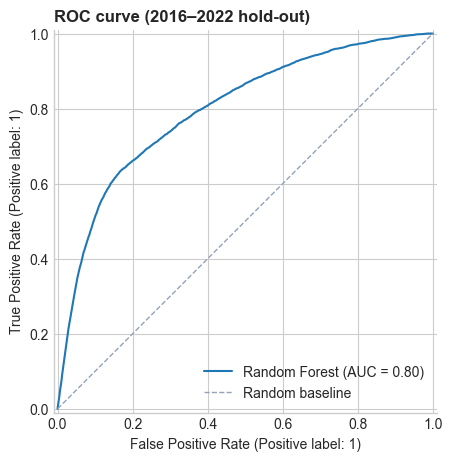

In [27]:
fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="#94a3b8", linewidth=1, label="Random baseline")
ax.set_title("ROC curve (2016–2022 hold-out)", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
clean_axes(ax)

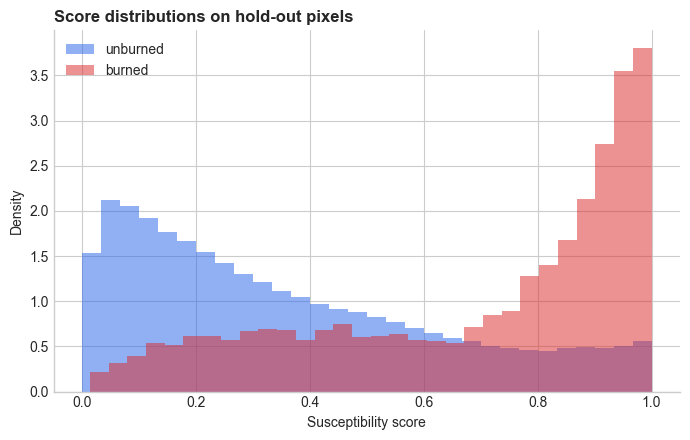

In [28]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for target, label, color in [(0, "unburned", "#2563eb"), (1, "burned", "#dc2626")]:
    ax.hist(
        test_scores.loc[test_scores["target"] == target, "score"],
        bins=30,
        density=True,
        alpha=0.5,
        color=color,
        label=label,
    )
ax.set_title("Score distributions on hold-out pixels", loc="left", fontweight="bold")
ax.set_xlabel("Susceptibility score")
ax.set_ylabel("Density")
clean_axes(ax)
ax.legend(frameon=False)
fig.tight_layout()



## 10. Threshold decisions

*Learning objective:* understand that a threshold is a *decision rule*, not
a property of the model, and that percentile-based thresholds are more
portable than raw score cutoffs.

The Random Forest outputs a continuous score. Turning it into a binary
class ("high susceptibility" vs "low") requires choosing a threshold.
There is **no universal wildfire threshold**. The right choice depends on
the cost of:
- Missing susceptible areas (false negatives → unmanaged risk)
- Over-flagging low-susceptibility areas (false positives → wasted resources)

### Percentile thresholds

Rather than a raw score cutoff (which depends on model internals), define
"high susceptibility" as a *territory share*: e.g., the top 10%, 25%, or
50% of valid pixels by model score. This is easier to explain to
stakeholders and robust to model recalibration.

In [29]:
baseline_burned_share = test_scores["target"].mean()

operational_threshold_rows = []
for high_risk_share in [0.10, 0.25, 0.50]:
    score_threshold = test_scores["score"].quantile(1 - high_risk_share)
    selected = test_scores["score"] >= score_threshold
    operational_threshold_rows.append(
        {
            "high_risk_territory_%": f"{high_risk_share:.0%}",
            "score_threshold": round(score_threshold, 3),
            "mapped_share": f"{float(selected.mean()):.1%}",
            "captured_burn_%": f"{recall_score(y_test, selected, zero_division=0):.1%}",
        }
    )

operational_threshold_df = pd.DataFrame(operational_threshold_rows)
display(Markdown("### Percentile thresholds on 2016–2022 hold-out"))
display(operational_threshold_df)

### Percentile thresholds on 2016–2022 hold-out

,high_risk_territory_%,score_threshold,mapped_share,captured_burn_%
0,10%,0.810,10.0%,49.5%
1,25%,0.547,25.2%,69.8%
2,50%,0.293,50.3%,86.5%


The trade-off is clear: a smaller high-susceptibility zone is cheaper to
inspect but misses more burned pixels. The top 10% captures ~50% of fires;
the top 50% captures ~90%. The "right" threshold is a policy decision.

In [30]:
medium_threshold = test_scores["score"].quantile(0.50)
high_threshold = test_scores["score"].quantile(0.75)

test_scores["susceptibility_class"] = pd.cut(
    test_scores["score"],
    bins=[-np.inf, medium_threshold, high_threshold, np.inf],
    labels=["low", "medium", "high"],
    include_lowest=True,
)

susceptibility_class_df = (
    test_scores.groupby("susceptibility_class", observed=True)
    .agg(
        pixels=("target", "size"),
        territory_share=("target", lambda v: len(v) / len(test_scores)),
        mean_score=("score", "mean"),
        burned_pixels=("target", "sum"),
        observed_burn_rate=("target", "mean"),
    )
    .reset_index()
)
susceptibility_class_df["captured_burn_share"] = (
    susceptibility_class_df["burned_pixels"] / test_scores["target"].sum()
)
susceptibility_class_df["lift"] = (
    susceptibility_class_df["observed_burn_rate"] / baseline_burned_share
).round(1)
display(Markdown("### Susceptibility classes on hold-out"))
display(susceptibility_class_df)

### Susceptibility classes on hold-out

,susceptibility_class,pixels,territory_share,mean_score,burned_pixels,observed_burn_rate,captured_burn_share,lift
0,low,200005,0.501647,0.138124,806,0.004030,0.138822,0.3
1,medium,99232,0.248891,0.411741,960,0.009674,0.165346,0.7
2,high,99460,0.249463,0.763700,4040,0.040619,0.695832,2.8


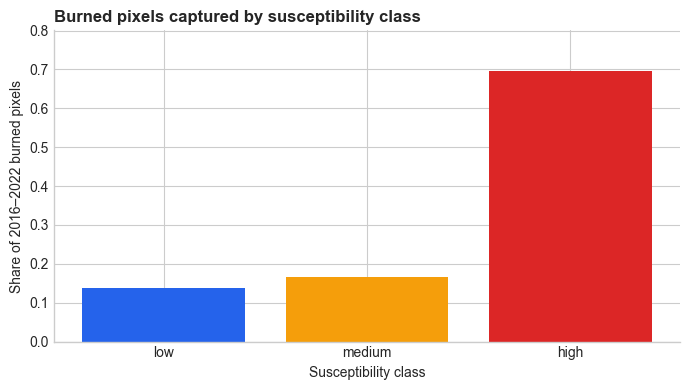

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))
class_plot_df = susceptibility_class_df.set_index("susceptibility_class").loc[
    ["low", "medium", "high"]
]
ax.bar(
    class_plot_df.index,
    class_plot_df["captured_burn_share"],
    color=["#2563eb", "#f59e0b", "#dc2626"],
)
ax.set_title("Burned pixels captured by susceptibility class", loc="left", fontweight="bold")
ax.set_xlabel("Susceptibility class")
ax.set_ylabel("Share of 2016–2022 burned pixels")
ax.set_ylim(0, max(0.05, class_plot_df["captured_burn_share"].max() * 1.15))
clean_axes(ax)
fig.tight_layout()

### Balanced confusion matrix (pedagogical diagnostic)

Confusion matrices are hard to interpret on the full landscape where
unburned pixels outnumber burned pixels 20:1. For a clearer diagnostic,
we subsample a 50/50 test set from the 2016–2022 hold-out.

This balanced matrix shows whether the model has learned a real signal,
but it does **not** represent landscape-level precision or false-alarm rates.

Text(0.0, 1.0, 'Balanced hold-out (threshold = 0.5)')

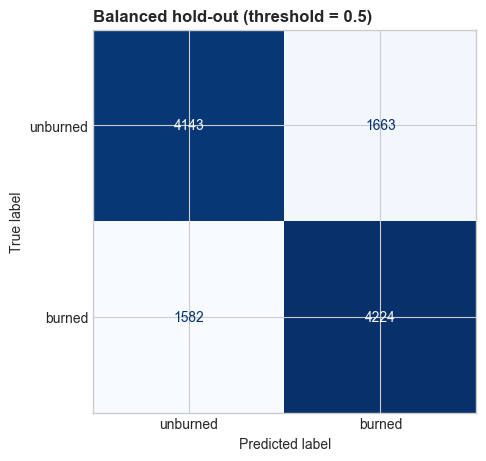

In [32]:
burned_test_scores = test_scores.loc[test_scores["target"] == 1]
unburned_test_scores = test_scores.loc[test_scores["target"] == 0].sample(
    n=len(burned_test_scores),
    random_state=RANDOM_STATE,
)
balanced_test_scores = (
    pd.concat([burned_test_scores, unburned_test_scores], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

balanced_confusion_threshold = 0.50
balanced_test_prediction = balanced_test_scores["score"] >= balanced_confusion_threshold

fig, ax = plt.subplots(figsize=(5, 4.5), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    balanced_test_scores["target"],
    balanced_test_prediction,
    display_labels=["unburned", "burned"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(
    f"Balanced hold-out (threshold = {balanced_confusion_threshold})",
    loc="left",
    fontweight="bold",
)

In [33]:
tn, fp, fn, tp = (
    int((~balanced_test_prediction & (balanced_test_scores["target"] == 0)).sum()),
    int((balanced_test_prediction & (balanced_test_scores["target"] == 0)).sum()),
    int((~balanced_test_prediction & (balanced_test_scores["target"] == 1)).sum()),
    int((balanced_test_prediction & (balanced_test_scores["target"] == 1)).sum()),
)

balanced_metrics_df = pd.DataFrame(
    [
        {
            "threshold": balanced_confusion_threshold,
            "accuracy": round((tp + tn) / (tp + tn + fp + fn), 3),
            "sensitivity (recall)": round(tp / (tp + fn), 3),
            "specificity": round(tn / (tn + fp), 3),
            "precision": round(tp / (tp + fp), 3),
            "F1": round(2 * tp / (2 * tp + fp + fn), 3),
        }
    ]
)
display(Markdown("### Balanced confusion metrics"))
display(balanced_metrics_df)

### Balanced confusion metrics

,threshold,accuracy,sensitivity (recall),specificity,precision,F1
0,0.5,0.721,0.728,0.714,0.718,0.722


Both sensitivity and specificity around 70–75% confirm the model has learned
a real discriminative signal. The balanced F1 ~ 0.72 is a decent baseline.
However, for susceptibility mapping the full-landscape ROC-AUC and
recall@top% metrics (Section 9) are the primary performance indicators.





## 11. Model explanation

*Learning objective:* understand permutation importance (MDA = Mean Decrease
in Accuracy) as a model-specific explanation tool, and distinguish it from
causal attribution.

**How it works:**
1. Shuffle one predictor column in the hold-out data.
2. Re-score the model.
3. Measure how much ROC-AUC drops compared to the unshuffled baseline.

A large drop means the model relied heavily on that variable for its
ranking. We compute importance on the *hold-out set* (not training data)
to measure what the model uses for generalization, not just for fitting.

> ⚠️ **Interpretation limits:**
> - Importance reflects model reliance, not ecological causality.
> - Correlated predictors share importance (e.g., elevation and vegetation
>   are confounded with geography).
> - Vegetation class can proxy for fuel structure, land management, climate
>   zone, and geography — permutation importance cannot separate these.

In [34]:
def raw_feature_auc(model, raw_X, y):
    """Custom scorer: encode raw features, then compute ROC-AUC."""
    encoded_X = make_features(raw_X, FEATURE_COLUMNS)
    return roc_auc_score(y, fire_score(model, encoded_X))


importance = permutation_importance(
    rf_model,
    test_df[FEATURES],
    y_test,
    scoring=raw_feature_auc,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": FEATURES,
            "AUC_drop": importance.importances_mean.round(4),
            "std": importance.importances_std.round(4),
        }
    )
    .sort_values("AUC_drop", ascending=False)
    .reset_index(drop=True)
)
display(Markdown("### Permutation importance (hold-out ROC-AUC drop)"))
display(importance_df)

### Permutation importance (hold-out ROC-AUC drop)

,feature,AUC_drop,std
0,vegetation,0.1737,0.0019
1,aspect_northness,0.0559,0.0020
2,elevation,0.0447,0.0008
3,slope,0.0420,0.0019
4,urban_distance,0.0353,0.0005
5,roads_distance,0.0295,0.0017
6,aspect_eastness,0.0144,0.0007


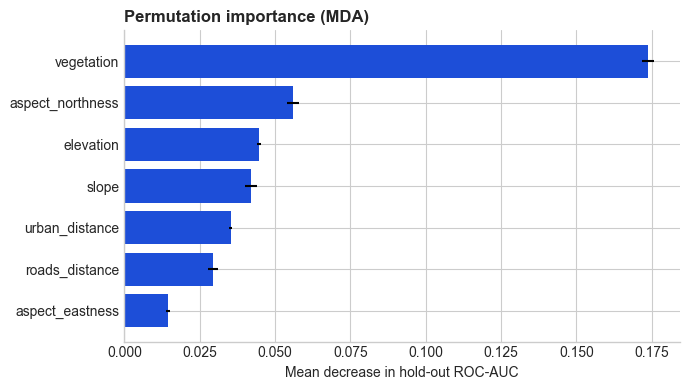

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = importance_df.sort_values("AUC_drop")
ax.barh(plot_df["feature"], plot_df["AUC_drop"], xerr=plot_df["std"], color="#1d4ed8")
ax.set_title("Permutation importance (MDA)", loc="left", fontweight="bold")
ax.set_xlabel("Mean decrease in hold-out ROC-AUC")
clean_axes(ax)
fig.tight_layout()

Vegetation is typically the dominant predictor, followed by aspect
(northness), elevation, and slope. This is consistent with the exploratory
analysis: vegetation class and south-facing exposure produce the clearest
separation between burned and unburned samples in this Ligurian study area.

## 12. Susceptibility map

*Learning objective:* produce a spatial prediction and understand that the
map is a model product, not independent evidence of accuracy.

The map uses `rf_model` (fitted on the full pre-2016 balanced pool with
tuned hyperparameters). Red contours overlay the 2016–2022 burned areas
for visual comparison, but the numeric metrics in Section 9 are the formal
evaluation.

In [36]:
grid_features = make_features(feature_table, FEATURE_COLUMNS)
grid_scores = fire_score(rf_model, grid_features)

susceptibility_grid = np.full(TEMPLATE_SHAPE, np.nan, dtype=float)
grid_rows = feature_table["row"].to_numpy()
grid_cols = feature_table["col"].to_numpy()
susceptibility_grid[grid_rows, grid_cols] = grid_scores

grid_score_summary = pd.Series(grid_scores).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
display(Markdown("### Mapped susceptibility score summary"))
display(grid_score_summary)

### Mapped susceptibility score summary

count    398697.000000
mean          0.362283
std           0.274410
min           0.000000
10%           0.056667
25%           0.130000
50%           0.293333
75%           0.546667
90%           0.810000
max           1.000000
dtype: float64

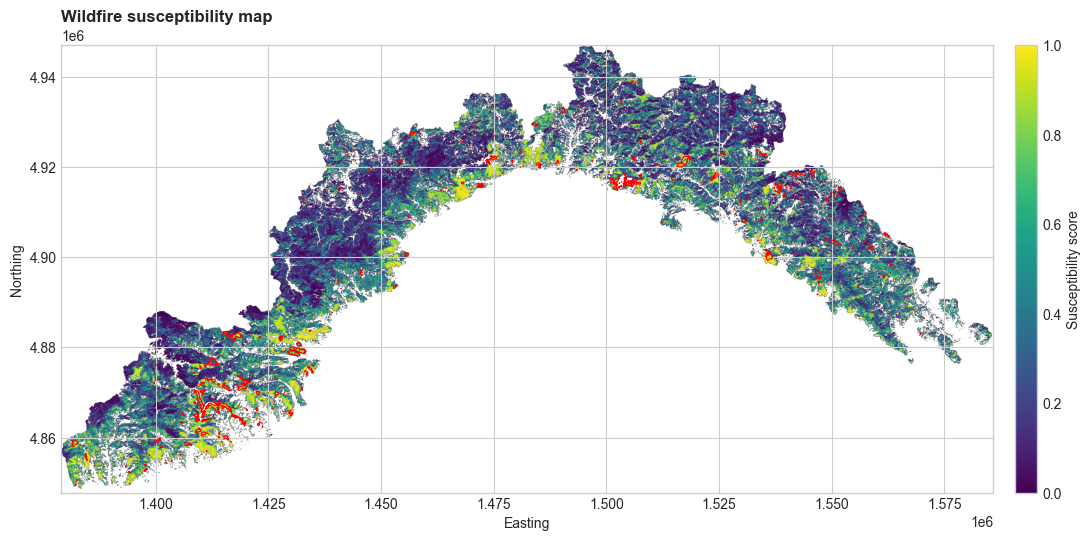

In [37]:
fig, ax = plt.subplots(figsize=(12, 5.5))
image = ax.imshow(
    susceptibility_grid, extent=extent, origin="upper", cmap="viridis", vmin=0, vmax=1
)

# Overlay: true 2016–2022 burned areas (visual comparison only).
holdout_burned_overlay = test_burned_mask & valid_mask
ax.contour(
    holdout_burned_overlay.astype(int),
    levels=[0.5],
    extent=extent,
    origin="upper",
    colors="red",
    linewidths=0.8,
)

ax.set_title("Wildfire susceptibility map", loc="left", fontweight="bold")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal", adjustable="box")
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02, label="Susceptibility score")
fig.tight_layout()

## Take-home messages

1. **Raster → table:** Spatial raster data can be converted into a standard
   supervised-learning problem (one row per pixel, one column per feature).

2. **Temporal validation:** Training on past fires and evaluating on future
   fires is a stronger test than random splits, because it simulates the
   operational use case.

3. **Pseudo-absences:** Balanced sampling gives the model enough contrast to
   learn, but the resulting scores are rankings, not calibrated probabilities.

4. **Feature engineering matters:** Circular variables (aspect) need
   trigonometric decomposition; unordered categories (vegetation) need
   one-hot encoding.

5. **Evaluation metrics:** ROC-AUC and recall@top% are appropriate for
   ranking tasks. Accuracy is misleading under extreme class imbalance.

6. **Thresholds are decisions:** Converting a score into a class requires a
   policy choice. Percentile-based thresholds (top 10%, 25%, 50%) are more
   portable and interpretable than raw score cutoffs.

7. **Model explanation ≠ causality:** Permutation importance shows what the
   model relies on, not what drives fire occurrence.

8. **Spatial autocorrelation:** Nearby pixels share predictors and fire
   history. Random validation splits are optimistic; temporal and spatial
   hold-outs are more honest.

9. **The map is a model product:** It should be interpreted with the sampling
   design, predictor limitations, and validation results in mind.

## Exercises

1. **Add climate predictors.**
   Extend `RASTER_PATHS`, `RASTER_FEATURES`, and `FEATURES` with:
   `temperature_summer.tif`, `temperature_winter.tif`,
   `precipitation_summer.tif`, `precipitation_winter.tif`.
   Re-run the workflow and compare hold-out ROC-AUC and recall@top%.
   Do the climate variables appear in the MDA table?

2. **Try another algorithm.**
   Replace `RandomForestClassifier` with `XGBClassifier`,
   `ExtraTreesClassifier`, or `LogisticRegression`. Keep the same splits.
   Compare validation metrics, hold-out metrics, and score distributions.
   Which model produces sharper score separation?

3. **Spatial cross-validation.**
   Design a geographic split (e.g., by easting or northing). Train on one
   part of the study area, test on the other. Compare with the temporal
   split. Does the model generalize spatially? What does a geographic split
   test that a temporal split does not?

4. **Vary the pseudo-absence ratio.**
   Try 1:2 and 1:5 unburned:burned ratios instead of 1:1. How does this
   change the score distribution, the ROC-AUC, and the confusion matrix?
   When might a higher ratio be preferable?
